# Seminar 2. Linear Regression

Given **X** is the feature matrix, **y** is the target,

and **dataset** $\{X_i, y_i\}_{i=1}^K$, where $X_i \in \mathbb{R}^N$, $y_i \in \mathbb{R}$


The general equation for a **Linear Regression Model** is:

$
\hat{y} = Xw = w_0 + w_1x_1 + w_2x_2 + ... + w_nx_n
$

where:
- $\hat{y}$ - prediction
- $x_1, x_2, ..., x_n$ - features
- $w_0$ - bias
- $w_1, w_2, ..., w_n$ - weights

## Dataset

Generate the feature matrix $X$ and correct weights $w_{\text{true}}$:

In [ ]:
import numpy as np

n_objects = 100
n_features = 2

X = np.random.uniform(-10, 10, (n_objects, n_features))

X[:3]

array([[-7.08106223, -4.9719236 ],
       [ 4.66838787,  1.6833913 ],
       [-8.15851166,  6.10958579]])

In [ ]:
w_true = np.random.normal(0, 1, n_features)

w_true

array([-0.3562982 , -0.00495897])

The target vector (in a general case, matrix) is computed as $y = X w_{\text{true}} + \epsilon$ (with the gaussian noise):

In [ ]:
y = X.dot(w_true) + np.random.uniform(-1, 1, n_objects)

y[:3]

array([ 3.14908117, -2.07021822,  2.7023582 ])

Split the dataset to the train and test parts:

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3)

Visualize the dataset:

In [ ]:
import plotly.graph_objects as go
import plotly.express as px

# Create a grid for the regression plane
X1_grid, X2_grid = np.meshgrid(np.linspace(X[:, 0].min(), X[:, 0].max(), 20),
                               np.linspace(X[:, 1].min(), X[:, 1].max(), 20))
y_grid = w_true[0] * X1_grid + w_true[1] * X2_grid

# Create a 3D scatter plot with the regression plane
fig_3d = go.Figure()

# Add training data points
fig_3d.add_trace(go.Scatter3d(x=X_train[:, 0], y=X_train[:, 1], z=y_train,
                              mode='markers', marker=dict(size=5, color='blue'),
                              name="Train Data"))

# Add test data points
fig_3d.add_trace(go.Scatter3d(x=X_test[:, 0], y=X_test[:, 1], z=y_test,
                              mode='markers', marker=dict(size=5, color='red'),
                              name="Test Data"))

# Add regression plane
fig_3d.add_trace(go.Surface(z=y_grid, x=X1_grid, y=X2_grid, colorscale='Viridis', opacity=0.7))

# Update layout
fig_3d.update_layout(title="3D Regression Plane",
                     scene=dict(xaxis_title="Feature 1",
                                yaxis_title="Feature 2",
                                zaxis_title="Target (y)"),
                     margin=dict(l=0, r=0, b=0, t=40))

fig_3d.show()

#### Questions

<details><summary>What role do the weights (coefficients) and bias play in the model?</summary>

- Weights determine how much each feature contributes to the predicted output. A higher absolute value of a coefficient means that the corresponding feature has a stronger influence on the prediction.
- Bias shifts the prediction up or down. It represents the expected output when all features are zero. Without the bias term, the model would be forced to pass through the origin, which may not always be correct.
    
</details>

<details><summary>What happens when we try to fit a linear model to data that is non-linear?</summary>

A linear model assumes a straight-line relationship between inputs and outputs. If the data follows a curved or complex pattern, the linear model fails to capture the relationship, leading to high bias and poor predictions.

The residuals (errors) will not be randomly distributed, indicating a bad model fit.
</details>

<details><summary>Can you think of a real-world example where Linear Regression could be used?</summary>

A real estate company wants to predict the price of a house using factors such as: size, number of bedrooms and bathrooms, distance to city center, age of the house.

Works well when the relationship between features and price is mostly linear.

Fails when price depends on complex factors like neighborhood trends or luxury upgrades (which may require non-linear models).

By adding more relevant features, such as neighborhood trends (e.g., proximity to parks, restaurants, schools, or crime rates), we can transform a seemingly non-linear problem into a linear one in a higher-dimensional space.

This idea is closely related to Cover’s Theorem (often used in the context of kernel methods in SVMs): A complex pattern that is non-linearly separable in a lower-dimensional space is more likely to become linearly separable when mapped into a higher-dimensional space.
</details>

<details><summary>What happens if we have too many features? How might this affect the model?</summary>

- As the number of features increases, the data points become more sparse in high-dimensional space (сurse of dimensionality). This makes the model harder to train and may lead to overfitting.
- When some features are highly correlated (multicollinearity), the model struggles to distinguish their individual effects. This leads to unstable coefficients, making interpretation difficult.
- More features mean higher computational cost, making training slower and more memory-intensive. In large datasets, this can be impractical.
</details>

## Analytical Solution

**Mean Squared Error (MSE)** loss function:

$L(w) = ||Y - Xw||_2^2 = (Y - Xw)^T (Y - Xw)$

To equate the gradient of the MSE loss function to zerro:

$\nabla_w L(w) = 0$

$ \nabla_w L(w) = \nabla_w [(Y - Xw)^T(Y - Xw)] = \nabla_w [Y^TY - Y^TXw - w^TX^TY + w^TX^TXw] = 0 - X^TY - (Y^TX)^T + 2X^TXw $

$ w = (X^TX)^{-1}Y^TX $

#### Question

Generally, the value of the function in the point where the gradient is zerro is the extremum of this function (we don't know it is the local maximum or minimum, or saddle point).

<details><summary>Why in this case are we sure that it is the minimum?</summary>

In Linear Regression, we minimize the Mean Squared Error (MSE) loss function. This function is a quadratic function of the weights, meaning it forms a paraboloid shape in high dimensions.
</details>


[Matrix calculus](https://en.wikipedia.org/wiki/Matrix_calculus)

In [ ]:
w = np.linalg.inv(X.T.dot(X)).dot(X.T).dot(y)

w

array([-0.37189024,  0.00974752])

In [ ]:
w_true

array([-0.3562982 , -0.00495897])

Compare the correct weights with the analitical solution:

In [ ]:
np.abs(w_true - w)

array([0.01559204, 0.01470649])

#### Question

<details>
    <summary>What problems may arise when using an analytical solution in real-world problems?</summary>

This solution is:
- unstable if there are multicollinear features
- expensive
    
</details>

[Invertible matrix](https://en.wikipedia.org/wiki/Invertible_matrix)

### Correlated features

In [ ]:
X_cor = np.copy(X)
X_cor[:, 1] = 2 * X_cor[:, 0]

y_cor = X_cor.dot(w_true) + np.random.normal(0, 1, n_objects)
w_cor = np.linalg.inv(X_cor.T.dot(X_cor)).dot(X_cor.T).dot(y_cor)

LinAlgError: Singular matrix

#### Question

Why do we have the error?

In [ ]:
X_cor = np.copy(X)
X_cor[:, 1] = X_cor[:, 0] + np.random.normal(0, 1e-3, n_objects)

y_cor =  X_cor.dot(w_true) + np.random.normal(0, 1, n_objects)
w_cor = np.linalg.inv(X_cor.T.dot(X_cor)).dot(X_cor.T).dot(y_cor)

In [ ]:
w_cor2 = np.linalg.inv(X_cor[4:].T.dot(X_cor[4:])).dot(X_cor[4:].T).dot(y_cor[4:])

In [ ]:
w_true = np.random.normal(0, 1, n_features)

w_true

array([-0.17652405,  0.34059536])

In [ ]:
w_cor

array([ 197.47330031, -197.99877311])

In [ ]:
w_cor2

array([ 193.29843093, -193.81932669])

In [ ]:
np.mean((y_cor - X_cor[:,0] * sum(w_true))**2)

np.float64(1.7206258137431276)

In [ ]:
np.mean((y_cor -X_cor.dot(w_true))**2)

np.float64(1.7208839792686248)

In [ ]:
y_cor =  X_cor.dot(w_true) + np.random.normal(0, 1, n_objects)
w_cor = np.linalg.inv(X_cor.T.dot(X_cor)).dot(X_cor.T).dot(y_cor)

In [ ]:
w_cor

array([ 61.32755621, -61.18952406])

In [ ]:
sum(w_true)

np.float64(0.16407131814050593)

In [ ]:
sum(w_cor)

np.float64(0.13803215110436895)

In [ ]:
w_cor

array([ 61.32755621, -61.18952406])

In [ ]:
np.abs(w_true - w_cor)

array([61.50408026, 61.53011942])

#### Question

<details>
<summary>Why are our correct weights so different from the analytical solution?</summary>

The analytical solution for linear regression is given by:
$w = (X^T X)^{-1} X^T y$
    
If our computed weights differ significantly from the expected values, it is likely due to:
    
- **Singular or Near-Singular Matrix**: If \(X^T X\) is singular (due to multicollinearity or insufficient data), the inversion is unstable.  
- **Numerical Instability**: If \(X^T X\) has a high condition number, small errors in data can lead to large deviations in weights.  
- **Noise in Data**: The presence of random noise can cause differences between theoretical and estimated weights.  
  
</details>

<details>
<summary>Is there the unique solution in this case?</summary>
    
Not always. A unique solution exists **if $X^T X$ is full-rank** (i.e., no linear dependencies).
    
However, if $X$ has:  

- **More features than samples** (underdetermined system), there are infinitely many solutions.  
- **Linearly dependent columns**, $X^T X$ is singular, making the inverse undefined.
</details>

<details>
<summary>How can we choose the more appropriate solution?</summary>

If there is no unique solution, we can:
    
- Apply **regularization** (e.g., Ridge regression) to stabilize the solution:  

$w = (X^T X + \lambda I)^{-1} X^T y$
    
- Use **dimensionality reduction** (e.g., PCA) to remove redundant features.
    
</details>

## Regularization

$$L(w) = ||Y - (X + \lambda I)w||_2^2 = ||Y-Xw||_2^2 + \lambda^2||w||_2^2$$

$$\hat{w} = (X^TX + \lambda I)^{-1} X^TY$$

In [ ]:
sum(w_true)

np.float64(0.16407131814050593)

In [ ]:
l = 0.0005
w_cor = np.linalg.inv(X_cor.T.dot(X_cor) + l * np.eye(n_features)).dot(X_cor.T).dot(y_cor)

sum(w_cor)

np.float64(0.13821168908613313)

In [ ]:
l = 0.1
w_cor = np.linalg.inv(X_cor.T.dot(X_cor) + l * np.eye(n_features)).dot(X_cor.T).dot(y_cor)

np.abs(w_true - w_cor)

array([0.27041334, 0.29626053])

In [ ]:
l = 0.01
w_cor = np.linalg.inv(X_cor.T.dot(X_cor) + l * np.eye(n_features)).dot(X_cor.T).dot(y_cor)

np.abs(w_true - w_cor)

array([2.05347825, 1.03129805])

## Gradient Descent

The analytical solution described above includes invertion of the matrix $X^T X$ (or $X^T X + \lambda I$),

which is quite expensive in terms of computation resourses.

Using the **gradient descent**, the weights vector $w^{(t+1)}$ on step $t+1$ can be expressed in the following form:

$ w^{(t+1)} = w^{(t)} - \eta_t \nabla L(w^{(t)})$

where $\eta_t$ stays for the gradient step (usually referred as *learning rate*).

The gradient in case of MSE loss function takes the following form:

$\nabla L(w) = -2X^TY + 2X^TXw = 2X^T(Xw - Y)$

In [ ]:
n_objects = 100
n_features = 2

X = np.random.uniform(-10, 10, (n_objects, n_features))

w_true = np.random.normal(0, 1, n_features)
y = X.dot(w_true) + np.random.uniform(-5, 5, n_objects)

#### Question

<details>
    <summary>What do we need to do before starting the iteration process?</summary>
    
Initialize weights with random numbers
    
</details>

In [ ]:
w_0 = np.random.uniform(-1, 1, n_features)

In [ ]:
num_steps = 10
learning_rate = 0.01 # eta

w = w_0.copy()
w_list = [w.copy()]

for i in range(num_steps):
    w -= learning_rate * 2. * np.dot(X.T, (X.dot(w) - y)) / len(y)
    w_list.append(w.copy())

w_list = np.array(w_list)

In [ ]:
w_an = np.linalg.inv(X.T.dot(X)).dot(X.T).dot(y)
w_an

array([ 0.55619156, -0.00629567])

In [ ]:
w

array([ 0.55573297, -0.00587742])

In [ ]:
w_true

array([0.54408073, 0.02754511])

In [ ]:
np.abs(w_true - w)

array([0.01165225, 0.03342253])

In [ ]:
X_cor.dot(w_true)

array([ 2.06238356, -1.64187502, -4.06124813, -2.68119823, -0.06617239,
        2.7592457 ,  1.1128474 , -4.29991548, -2.12874373,  5.1198434 ,
       -0.67165509, -5.34755816, -0.33764696,  2.01181397, -1.82938256,
        5.68475064, -1.24732294, -3.89192027, -3.48585036,  0.31580447,
        3.81492338,  4.05281502, -2.01569739, -1.30975968,  0.70405831,
        0.87573227, -1.06423654,  3.85323337, -1.42727376,  2.34953872,
       -5.03108754,  0.12704539, -4.86401216, -0.1461586 , -5.17209489,
       -1.74233802,  5.45033117, -4.34914118, -2.43039814,  4.71086843,
        2.98805276,  1.868812  ,  1.88806794,  4.96514963, -0.18589774,
       -4.98373946, -2.02669701, -4.13241798,  3.99631525,  4.49561923,
        1.07518638, -5.63972908,  5.50760972,  0.43991237,  0.48056133,
        2.17291041, -2.80931639,  1.04357598, -0.05552303, -1.80294372,
       -2.64739891, -1.12600118,  0.9819715 , -4.28589246, -3.42719366,
        5.7073735 ,  3.07050397, -1.405727  ,  0.19422938,  0.98

Visualize the process of Gradient Descent:

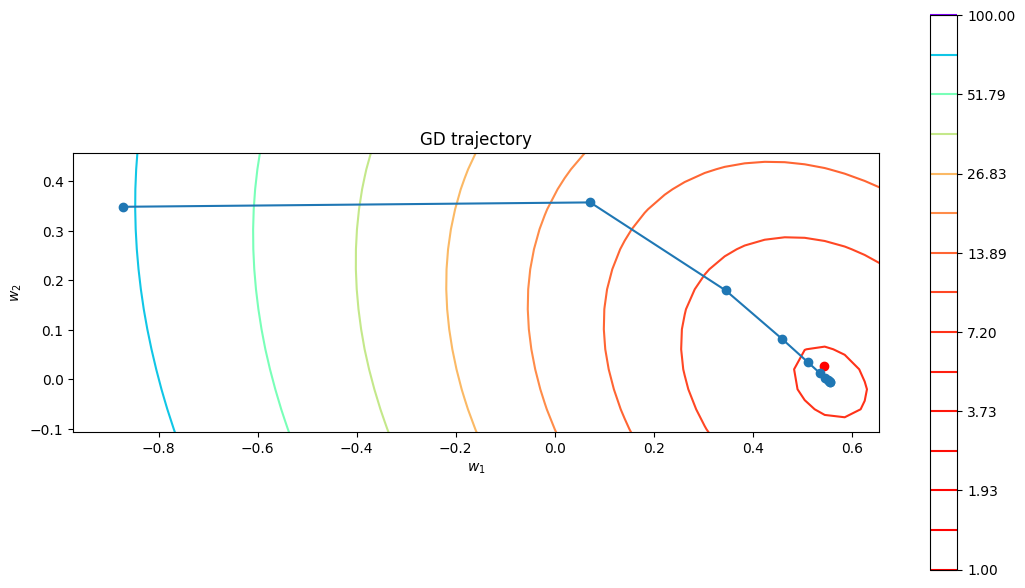

In [ ]:
import matplotlib.pyplot as plt

A, B = np.meshgrid(np.linspace(-2, 2, 100), np.linspace(-2, 2, 100))

levels = np.empty_like(A)
for i in range(A.shape[0]):
    for j in range(A.shape[1]):
        w_tmp = np.array([A[i, j], B[i, j]])
        levels[i, j] = np.mean(np.power(np.dot(X, w_tmp) - y, 2))

plt.figure(figsize=(13, 9))
plt.title('GD trajectory')
plt.xlabel('$w_1$')
plt.ylabel('$w_2$')
plt.xlim(w_list[:, 0].min() - 0.1, w_list[:, 0].max() + 0.1)
plt.ylim(w_list[:, 1].min() - 0.1, w_list[:, 1].max() + 0.1)
plt.gca().set_aspect('equal')

# visualize the level set
CS = plt.contour(A, B, levels, levels=np.logspace(0, 2, num=15), cmap=plt.cm.rainbow_r)
CB = plt.colorbar(CS, shrink=0.8, extend='both')

# visualize trajectory
plt.scatter(w_true[0], w_true[1], c='r')
plt.scatter(w_list[:, 0], w_list[:, 1])
plt.plot(w_list[:, 0], w_list[:, 1])

plt.show()

#### Questions

<details>
<summary>What happens if the learning rate is too small? Too large?</summary>

The learning rate controls how big the steps are when updating the weights during gradient descent. Choosing the right value is crucial for efficient and stable learning.

If **learning rate is too small**: The model converges safely (no risk of overshooting the minimum), but it needs to take too many iterations to reach the minimum (it produces higher computational cost) and may get stuck in a local minimum for a long time.

If **learning rate is too big**: The model can reach the minimum quickly, but may overshoot the minimum, jumping back and forth without convergence.
</details>

<details>
<summary>Why is a fixed learning rate not always the best choice?</summary>

A fixed learning rate may be too high (causing divergence) or too low (leading to slow convergence). A decaying or adaptive learning rate often improves performance by adjusting to different training phases.
</details>

<details>
<summary>Is learning rate is a parameter or an hyperparameter for our model?</summary>
    
The learning rate is an hyperparameter.
    
</details>

## Stochastic Gradient Descent

#### Questions

<details>
<summary>How exactly do we add the stochastic component in Gradient Descent?</summary>

In Batch Gradient Descent, we update weights using the full dataset. In Stochastic Gradient Descent (SGD), we update the weights using only one randomly chosen sample at a time.

Instead of averaging over all data points, SGD picks a random data point and updates the parameters, introducing randomness (stochasticity).
</details>

<details>
<summary>What problems does SGD solve compared to full-batch gradient descent?</summary>

High computation cost in full-batch GD (batch GD is too slow for large datasets).

Getting stuck in poor local minima (SGD’s noise helps escape sharp minima).

Memory limitations (SGD processes one sample at a time, so it can handle very large datasets).
</details>

In [ ]:
num_steps = 1000
learning_rate = 0.001
batch_size = 10

w_0 = np.random.uniform(-1, 1, n_features)

w = w_0.copy()
w_list = [w.copy()]

for i in range(num_steps):
    batch_indecies = np.random.randint(0, n_objects, batch_size)


    X_batch = X[batch_indecies, :]
    y_batch = y[batch_indecies]

    if i >= 35:
        learning_rate *= 0.95
    w -= learning_rate * 2. * np.dot(X_batch.T, (X_batch.dot(w) - y_batch)) / batch_size
    w_list.append(w.copy())

w_list = np.array(w_list)

In [ ]:
np.abs(w_true - w)

array([0.03194769, 0.02194908])

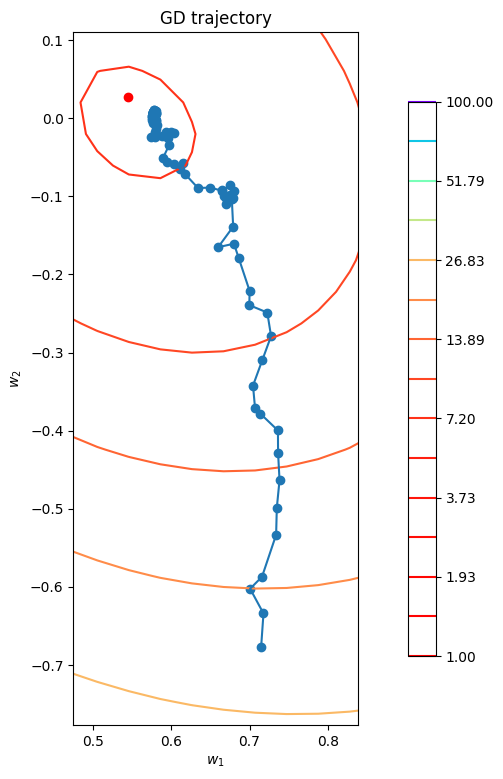

In [ ]:
A, B = np.meshgrid(np.linspace(-2, 2, 100), np.linspace(-2, 2, 100))

levels = np.empty_like(A)
for i in range(A.shape[0]):
    for j in range(A.shape[1]):
        w_tmp = np.array([A[i, j], B[i, j]])
        levels[i, j] = np.mean(np.power(np.dot(X, w_tmp) - y, 2))

plt.figure(figsize=(13, 9))
plt.title('GD trajectory')
plt.xlabel('$w_1$')
plt.ylabel('$w_2$')
plt.xlim(w_list[:, 0].min() - 0.1, w_list[:, 0].max() + 0.1)
plt.ylim(w_list[:, 1].min() - 0.1, w_list[:, 1].max() + 0.1)
plt.gca().set_aspect('equal')

# visualize the level set
CS = plt.contour(A, B, levels, levels=np.logspace(0, 2, num=15), cmap=plt.cm.rainbow_r)
CB = plt.colorbar(CS, shrink=0.8, extend='both')

# visualize trajectory
plt.scatter(w_true[0], w_true[1], c='r')
plt.scatter(w_list[:, 0], w_list[:, 1])
plt.plot(w_list[:, 0], w_list[:, 1])

plt.show()

## Custom version of Linear Regression

In [ ]:
from sklearn.base import BaseEstimator, RegressorMixin

class LinearRergessionSGD(BaseEstimator, RegressorMixin):
    def __init__(self, batch_size=25, lr=1e-3, num_steps=100):
        self.batch_size = batch_size
        self.lr = lr
        self.num_steps = num_steps

    def fit(self, X, y):
        n_objects = X.shape[0]
        n_features = X.shape[1]
        w = np.random.uniform(-1, 1, n_features)

        for i in range(self.num_steps):
            batch_indecies = np.random.randint(0, n_objects, self.batch_size)

            X_batch = X[batch_indecies, :]
            y_batch = y[batch_indecies]

            w -= self.lr * 2. * np.dot(X_batch.T, (X_batch.dot(w) - y_batch)) / self.batch_size

        self.w = w
        return self

    def predict(self, X):
        return X.dot(self.w)

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y)

lr = LinearRergessionSGD().fit(X_train, y_train)

lr.score(X_test, y_test)

0.44523473169853856

In [ ]:
np.mean(np.abs(w_true - lr.w))

np.float64(0.06102887910363062)

In [ ]:
n_objects = 100000
n_features =  1000

X = np.random.uniform(-10, 10, (n_objects, n_features))

w_true = np.random.normal(0, 1, n_features)
y = X.dot(w_true) + np.random.uniform(-5, 5, n_objects)

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y)

lr = LinearRergessionSGD().fit(X_train, y_train)

lr.score(X_test, y_test)

-139.16385287305295

In [ ]:
np.mean(np.abs(w_true - lr.w))

np.float64(9.152123041979381)

#### Question

<details>
    <summary>What is going on?</summary>
    
During our SGD we've encountered too big values to store in float. That leads us to feature normalization.

</details>

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

lr = LinearRergessionSGD().fit(X_train_scaled, y_train)

lr.score(X_test_scaled, y_test)

0.32004321239015265

In [ ]:
np.mean(np.abs(w_true - lr.w))

np.float64(0.5795944338844494)

#### Question

<details>
<summary>Could we fit the scaler on the all dataset and after split to the train and test?</summary>

If we fit the scaler on the whole dataset, information from the test set leaks into the training process, leading to **data leakage**. This can artificially improve performance and cause the model to generalize poorly on real-world data.
</details>

## Linear Regression out of the box

Finally, let's take a brief look at implemented versions of Linear Regression from sklearn. The main classes are:

* [LinearRegression](http://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LinearRegression.html) — classical linear regression (*actially, it is just `scipy.linalg.lstsq` wrapped with sklearn `Predictor` class) __analytical__ solver.
* [Lasso](http://scikit-learn.org/stable/modules/generated/sklearn.linear_model.Lasso.html) — Linear regression with L1 regularization.
* [Ridge](http://scikit-learn.org/stable/modules/generated/sklearn.linear_model.Ridge.html) — Linear regression with L2 regularization.

To minimize any other error function you are free to use [SGDRegressor](http://scikit-learn.org/stable/modules/generated/sklearn.linear_model.SGDRegressor.html) (or wait for a week and we will get the great *PyTorch* automatic differentiation engine).

Let's compare the speed of analytical and gradient solutions from the sklearn realizations.

IPython magic `%%time` wrapper will be used.

To measure the quality $R^2$ score will be used. It compares our model (`a`) with one always predicting mean `y`:

$$R^2 = 1 - \frac{\sum_i (y_i - a(x_i))^2}{\sum_i (y_i - \overline{y}_i)^2}$$

In [ ]:
import time

from sklearn.linear_model import LinearRegression, Lasso, Ridge

lr = LinearRegression()

time_begin = time.time()
lr.fit(X_train, y_train)
print(f'Time: {time.time() - time_begin}')
print(f'R2: {lr.score(X_test, y_test)}')

Time: 30.296350955963135
R2: 0.9997347282076203


In [ ]:
X_train.shape

(75000, 1000)

In [ ]:
lr = Ridge(alpha=0.0, solver='sparse_cg')

time_begin = time.time()
lr.fit(X_train, y_train)
print(f'Time: {time.time() - time_begin}')
print(f'R2: {lr.score(X_test, y_test)}')

Time: 1.0088090896606445
R2: 0.9997347252428074


In [ ]:
from sklearn.pipeline import make_pipeline

pipeline = make_pipeline(
    StandardScaler(),
    Ridge(alpha=0.0, solver='sparse_cg'),
)

time_begin = time.time()
pipeline.fit(X_train, y_train)
print(f'Time: {time.time() - time_begin}')
print(f'R2: {pipeline.score(X_test, y_test)}')

Time: 2.112889051437378
R2: 0.9997347249202976
